In [1]:
import pandas as pd

ruta = '../data/ecommerce_churn.csv'
df = pd.read_csv(ruta)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [2]:
# 1. Contamos exactamente cuántos datos nulos hay en cada columna
print("--- CANTIDAD DE NULOS POR COLUMNA ---")
print(df.isnull().sum())

# 2. Vemos las primeras 5 filas para entender el formato de los datos
print("\n--- PRIMERAS 5 FILAS ---")
display(df.head())

--- CANTIDAD DE NULOS POR COLUMNA ---
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

--- PRIMERAS 5 FILAS ---


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
# 1. Rellenamos los nulos de cada columna con su respectivo promedio (mean)
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].mean())
df['WarehouseToHome'] = df['WarehouseToHome'].fillna(df['WarehouseToHome'].mean())
df['DaySinceLastOrder'] = df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].mean())

# 2. Volvemos a contar los nulos para confirmar que la limpieza funcionó
print("--- REVISIÓN POST-LIMPIEZA ---")
print(df.isnull().sum())

--- REVISIÓN POST-LIMPIEZA ---
Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# 1. Traducir las columnas de texto a números (0 y 1)
df_numerico = pd.get_dummies(df, drop_first=True)

# 2. Separar las "pistas" (X) de la "respuesta correcta" (y)
X = df_numerico.drop('Churn', axis=1)
y = df_numerico['Churn']

# 3. Dividir los datos: 80% para entrenar y 20% para el examen final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("¡Datos listos y separados!")
print(f"Clientes usados para ENTRENAR (80%): {X_train.shape[0]}")
print(f"Clientes usados para PROBAR (20%): {X_test.shape[0]}")

¡Datos listos y separados!
Clientes usados para ENTRENAR (80%): 3152
Clientes usados para PROBAR (20%): 789


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Creamos el "cerebro" del modelo (100 árboles de decisión)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. ENTRENAMIENTO: Le pasamos los datos para que aprenda los patrones
print("Entrenando el modelo...")
modelo_rf.fit(X_train, y_train)

# 3. PREDICCIÓN: Le tomamos el "examen final" con el 20% de datos que no conoce
predicciones = modelo_rf.predict(X_test)

# 4. EVALUACIÓN: Comparamos sus respuestas con la realidad
precision = accuracy_score(y_test, predicciones)

print(f"\n🎯 Precisión global del modelo: {precision * 100:.2f}%\n")
print("📊 Reporte detallado de clasificación:")
print(classification_report(y_test, predicciones))

Entrenando el modelo...

🎯 Precisión global del modelo: 93.66%

📊 Reporte detallado de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       660
           1       0.85      0.74      0.79       129

    accuracy                           0.94       789
   macro avg       0.90      0.86      0.88       789
weighted avg       0.93      0.94      0.93       789



--- TOP 10 FACTORES QUE CAUSAN CHURN ---


,Variable,Importancia
0,Tenure,0.234620
7,CashbackAmount,0.166667
1,WarehouseToHome,0.113522
6,DaySinceLastOrder,0.094399
4,NumberOfAddress,0.084336
5,Complain,0.078796
3,SatisfactionScore,0.066385
2,NumberOfDeviceRegistered,0.053184
14,MaritalStatus_Single,0.034084
13,MaritalStatus_Married,0.020457


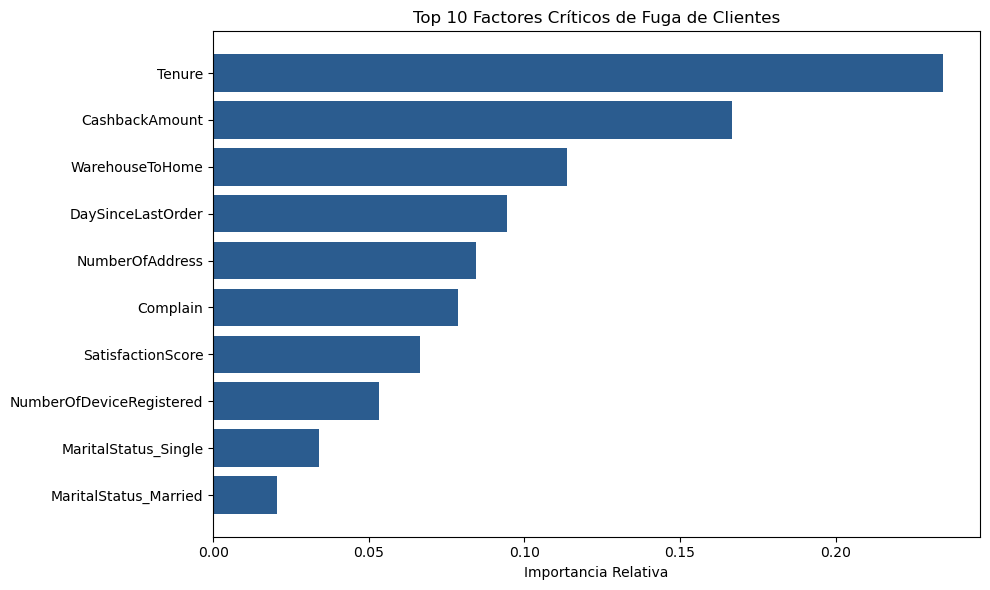

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraemos los puntajes de importancia de cada variable del modelo
importancias = modelo_rf.feature_importances_
columnas = X_train.columns

# 2. Armamos un DataFrame ordenado de mayor a menor
df_importancia = pd.DataFrame({
    'Variable': columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Mostramos las 10 variables más críticas en formato de tabla
print("--- TOP 10 FACTORES QUE CAUSAN CHURN ---")
display(df_importancia.head(10))

# 4. Generamos un gráfico horizontal rápido para visualizarlo
plt.figure(figsize=(10, 6))
top_10 = df_importancia.head(10).sort_values(by='Importancia', ascending=True)
plt.barh(top_10['Variable'], top_10['Importancia'], color='#2b5c8f')
plt.xlabel('Importancia Relativa')
plt.title('Top 10 Factores Críticos de Fuga de Clientes')
plt.tight_layout()
plt.show()

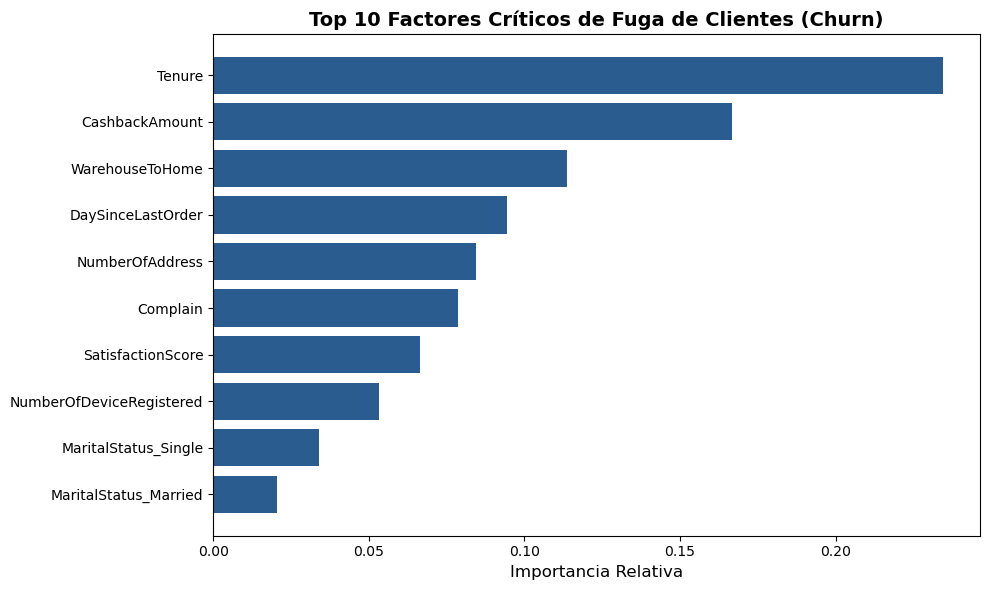

¡Gráfico guardado exitosamente en la carpeta 'reports'!


In [11]:
import os
import matplotlib.pyplot as plt

# 1. Creamos la carpeta 'reports' si no existe
os.makedirs('../reports', exist_ok='True')

# 2. Re-generamos el gráfico con alta calidad y lo guardamos
plt.figure(figsize=(10, 6))
top_10 = df_importancia.head(10).sort_values(by='Importancia', ascending=True)
plt.barh(top_10['Variable'], top_10['Importancia'], color='#2b5c8f')
plt.xlabel('Importancia Relativa', fontsize=12)
plt.title('Top 10 Factores Críticos de Fuga de Clientes (Churn)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Guardamos la imagen
plt.savefig('../reports/feature_importance.png', dpi=300)
plt.show()

print("¡Gráfico guardado exitosamente en la carpeta 'reports'!")